## testing seperate pcr-globwb run

In [1]:
from src.forcing import generate_PCRGLOBWB_ERA5_forcing
from pathlib import Path
import ewatercycle.observation.grdc
import matplotlib.pyplot as plt
from src.pcr_calibration_model import CalibrationObjective, normalize_params, denormalize_params
import numpy as np

import cma  # CMA-ES optimizer
from ewatercycle.container import ContainerImage

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:
SHAPEFILES = "/home/avandervee3/complete_pcrglob_run/data/shapefiles"
FORCING_PCRGLOB = "/home/avandervee3/complete_pcrglob_run/data/forcing"
FORCING_PATH_LOAD = Path(FORCING_PCRGLOB) / "output/PCRGLOBWB/ERA5_1948-1952/AralSea_basin"

In [3]:
# experiment_start_date = "1948-01-01T00:00:00Z"
# experiment_end_date = "1952-12-31T00:00:00Z"
# PCR_Forcing = generate_PCRGLOBWB_ERA5_forcing("AralSea_basin", experiment_start_date, experiment_end_date)

In [4]:
import yaml
from pathlib import Path

config_path = Path("data/configs/template.yaml")
with open(config_path) as f:
    config = yaml.safe_load(f)

config_dir = config_path.parent

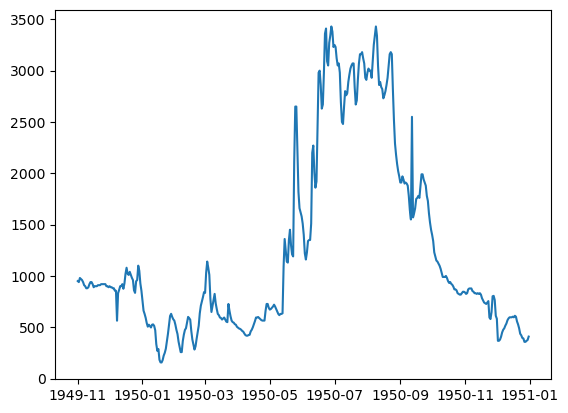

In [5]:
cal_start = config['model']['calibration_period']["start"]
cal_end = config['model']['calibration_period']["end"]

# Option 1: Load from GRDC
obs_data = ewatercycle.observation.grdc.get_grdc_data(
    data_home = (config_dir / config["paths"]["grdc_daily_dir"]).resolve(),
    station_id="2817100",
    start_time=cal_start,
    end_time=cal_end,
)

plt.plot(obs_data['time'], obs_data['streamflow'], label="Observed Discharge")

In [6]:
stations = []
for station in config["stations"]:
    obs = ewatercycle.observation.grdc.get_grdc_data(
        data_home=(config_dir / config["paths"]["grdc_daily_dir"]).resolve(),
        station_id=station["grdc_id"],
        start_time=cal_start,
        end_time=cal_end,
    )
    stations.append({
        "name": station["name"],
        "coords": {"lat": station["lat"], "lon": station["lon"]},
        "obs_data": obs,
        "weight": station.get("weight", 1.0),
    })

len(stations), [s["name"] for s in stations]

(3, ['Chatly', 'Garm', 'Uch-Kurgan'])

In [7]:
CALIBRATION_PARAMS = config['calibration_parameters']

output_dir = (config_dir / config["experiment"]["output_root"]).resolve()
template_ini = (config_dir / config["paths"]["template_ini"]).resolve()
params_dir = config["paths"]["params_dir"]
forcing_dir = (config_dir / config["paths"]["forcing_dir"]).resolve()
bmi_image = ContainerImage(config["model"]["bmi_image"])
study_area  = (config_dir / config["paths"]["clone_map"]).resolve()
SPINUP_DAYS = config['model']['spinup_days']
FORCE_GC_AFTER_RUN = True
REMOVE_RUN_DIR_AFTER_EVAL = False


In [8]:
output_dir

PosixPath('/home/avandervee3/complete_pcrglob_run/outputs')

In [9]:
obj = CalibrationObjective(
    stations=stations,
    calibration_params=CALIBRATION_PARAMS,
    output_dir=output_dir,
    template_ini=template_ini,
    params_dir=params_dir,
    forcing_dir=forcing_dir,
    bmi_image=bmi_image,
    clone_map=study_area,
    landmask=study_area,
    cal_start=cal_start,
    cal_end=cal_end,
    spinup_days=SPINUP_DAYS,
    model_version = "16mar",
    force_gc_after_run=FORCE_GC_AFTER_RUN,
    remove_run_dir_after_eval=REMOVE_RUN_DIR_AFTER_EVAL,
)

forcing_dir


PosixPath('/home/avandervee3/complete_pcrglob_run/data/forcing/output/PCRGLOBWB/ERA5_1948-1952/AralSea_basin/work/diagnostic/script')

In [10]:
forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(directory=forcing_dir)

In [11]:
# Get initial values and bounds for CMA-ES
param_names = list(config['calibration_parameters'].keys())
x0_original = [config['calibration_parameters'][p]['initial'] for p in param_names]

# Normalize initial values to [0, 1]

x0_normalized = normalize_params(np.array(x0_original), CALIBRATION_PARAMS)
# All parameters now have bounds [0, 1]
lower_bounds = [0.0] * len(param_names)
upper_bounds = [1.0] * len(param_names)

print(f"Starting CMA-ES calibration with {len(param_names)} parameters")
print(f"Original initial values: {x0_original}")
print(f"Normalized initial values: {x0_normalized.tolist()}")
print(f"Normalized bounds: [0, 1] for all parameters")

# CMA-ES options
options = {
    'maxiter': 3,  # Number of generations (increase for real calibration)
    'popsize': 3,   # Population size per generation
    'bounds': [lower_bounds, upper_bounds],
    'verb_disp': 1,  # Display every iteration
    'verb_log': 0,   # Don't create log files
    'tolfun': 1e-6,  # Termination criterion: function value tolerance
}

# Initial step size (sigma) - now reasonable for [0, 1] space
sigma0 = 0.2  # 20% of the [0, 1] range

# Run CMA-ES optimization
es = cma.CMAEvolutionStrategy(x0_normalized.tolist(), sigma0, options)
es.optimize(obj)

# Get results
result = es.result
best_params_normalized = result.xbest
best_params_original = denormalize_params(np.array(best_params_normalized),CALIBRATION_PARAMS)
best_fitness = result.fbest

print("\n" + "="*60)
print("CMA-ES CALIBRATION COMPLETE")
print("="*60)
print(f"Best NSE: {-best_fitness:.4f}")
print(f"Total function evaluations: {result.evaluations}")
print(f"Best parameters (original scale):")
for i, name in enumerate(param_names):
    print(f"  {name}: {best_params_original[i]:.6f}")
print(f"\nBest parameters (normalized): {best_params_normalized}")

Starting CMA-ES calibration with 9 parameters
Original initial values: [1.0, 1.0, 1.0, -273.15, 0.5, 0.04, 3.0, 1.0, 3.0]
Normalized initial values: [0.3333333333333333, 0.5454545454545454, 0.5, 0.5, 0.5, 0.368421052631579, 0.5555555555555556, 0.1111111111111111, 0.5555555555555556]
Normalized bounds: [0, 1] for all parameters
(1,3mirr1)-aCMA-ES (mu_w=1.0,w_1=100%) in dimension 9 (seed=446561, Tue Mar 24 16:10:40 2026)

Run a40726c4
Params: {'referenceEPotFactor': 1.242323491466908, 'precipitationFactor': 0.6795866169988807, 'temperatureFactor': 1.0615873697933171, 'temperatureConstant': -273.21287839320814, 'maximize_irrigation_threshold': 0.5209826338795662, 'manningsN': 0.03961387278086476, 'multiplier_for_storCap': 4.436192792239914, 'multiplier_for_recessionCoeff': 1.223428847410473, 'multiplier_for_kSat': 3.866517182523253}


  Chatly: NSE=-0.4464, KGE=-0.2435, obj=1.3449 (w=1.0)
  Garm: NSE=-0.0022, KGE=0.1304, obj=0.9359 (w=1.0)
  Uch-Kurgan: NSE=-0.3833, KGE=-0.2758, obj=1.3296 (w=1.0)
Run a40726c4, OBJ: 1.2035 (weighted mean across 3 station(s))

Run 5f298665
Params: {'referenceEPotFactor': 0.8974869493687626, 'precipitationFactor': 1.0270828457836698, 'temperatureFactor': 0.9664256404181639, 'temperatureConstant': -274.18742560296613, 'maximize_irrigation_threshold': 0.521715200767298, 'manningsN': 0.005655511198430228, 'multiplier_for_storCap': 3.969039624787372, 'multiplier_for_recessionCoeff': 1.7832981635010494, 'multiplier_for_kSat': 3.511095684826944}


  Chatly: NSE=0.5837, KGE=0.8136, obj=0.3013 (w=1.0)
  Garm: NSE=-0.3949, KGE=-0.4421, obj=1.4185 (w=1.0)
  Uch-Kurgan: NSE=-0.3240, KGE=-0.0926, obj=1.2083 (w=1.0)
Run 5f298665, OBJ: 0.9760 (weighted mean across 3 station(s))

Run d381559d
Params: {'referenceEPotFactor': 1.1663764284678007, 'precipitationFactor': 0.9894367735939124, 'temperatureFactor': 1.0912048372263021, 'temperatureConstant': -273.2605634712989, 'maximize_irrigation_threshold': 0.537242482400162, 'manningsN': 0.04062144295309269, 'multiplier_for_storCap': 3.783087112463859, 'multiplier_for_recessionCoeff': 0.9907417577208166, 'multiplier_for_kSat': 4.682902643363763}


KeyboardInterrupt: 